# density field

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# helper function
def _get_min_max(f_1, f_2, f_3, p0=0, p1=100):
    vmin = np.min([np.percentile(f_1, p0), np.percentile(f_2, p0), np.percentile(f_3, p0)])
    vmax = np.max([np.percentile(f_1, p1), np.percentile(f_2, p1), np.percentile(f_3, p1)])
    return vmin, vmax
    

In [2]:
def make_lognormal_density(
        N=128,
        rho0=1.0,
        sigma_s=1.0,
        spectral_index=11.0/3.0,
        seed=42):

    rng = np.random.default_rng(seed)

    #--------------------------------------------------
    # create Gaussian random field
    #--------------------------------------------------

    field = rng.normal(size=(N,N,N))

    field_hat = np.fft.fftn(field)

    #--------------------------------------------------
    # Fourier grid
    #--------------------------------------------------

    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    kz = np.fft.fftfreq(N) * N

    KX,KY,KZ = np.meshgrid(
        kx,ky,kz,indexing="ij"
    )

    K = np.sqrt(
        KX**2 + KY**2 + KZ**2
    )

    #--------------------------------------------------
    # apply power spectrum
    #--------------------------------------------------

    amp = np.zeros_like(K)

    mask = K > 0

    amp[mask] = (
        K[mask]
        ** (-0.5 * spectral_index)
    )

    field_hat *= amp

    #--------------------------------------------------

    
    # transform back
    #--------------------------------------------------

    s = np.real(
        np.fft.ifftn(field_hat)
    )

    #--------------------------------------------------
    # normalize
    #--------------------------------------------------

    s -= np.mean(s)

    s /= np.std(s)

    s *= sigma_s

    #--------------------------------------------------
    # lognormal transform
    #--------------------------------------------------

    rho = rho0 * np.exp(
        s - 0.5*sigma_s**2
    )

    return rho

In [3]:
N=128
density = make_lognormal_density(N=N)

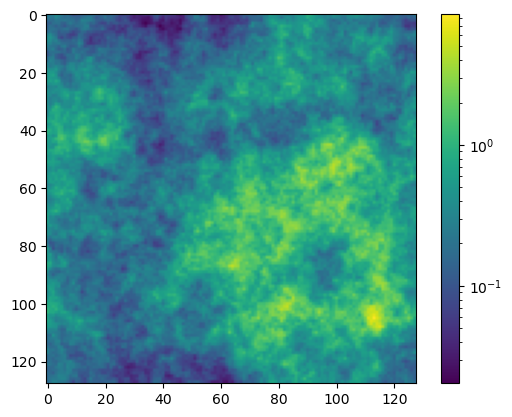

In [4]:
fig, ax = plt.subplots()
im = ax.imshow(density[:,:,N//2], norm = LogNorm())
fig.colorbar(im)

(array([1.451784e+06, 4.064150e+05, 1.295640e+05, 5.266100e+04,
        2.545800e+04, 1.337600e+04, 7.321000e+03, 4.057000e+03,
        2.502000e+03, 1.455000e+03, 9.360000e+02, 5.580000e+02,
        3.540000e+02, 2.130000e+02, 1.510000e+02, 1.000000e+02,
        5.700000e+01, 4.300000e+01, 3.400000e+01, 1.800000e+01,
        2.500000e+01, 1.500000e+01, 1.000000e+01, 7.000000e+00,
        1.000000e+01, 4.000000e+00, 2.000000e+00, 4.000000e+00,
        8.000000e+00, 0.000000e+00, 1.000000e+00, 0.000000e+00,
        2.000000e+00, 0.000000e+00, 2.000000e+00, 1.000000e+00,
        1.000000e+00, 1.000000e+00, 1.000000e+00, 1.000000e+00]),
 array([1.02883585e-02, 1.02117723e+00, 2.03206609e+00, 3.04295496e+00,
        4.05384383e+00, 5.06473269e+00, 6.07562156e+00, 7.08651043e+00,
        8.09739929e+00, 9.10828816e+00, 1.01191770e+01, 1.11300659e+01,
        1.21409548e+01, 1.31518436e+01, 1.41627325e+01, 1.51736214e+01,
        1.61845102e+01, 1.71953991e+01, 1.82062880e+01, 1.92171768e+01

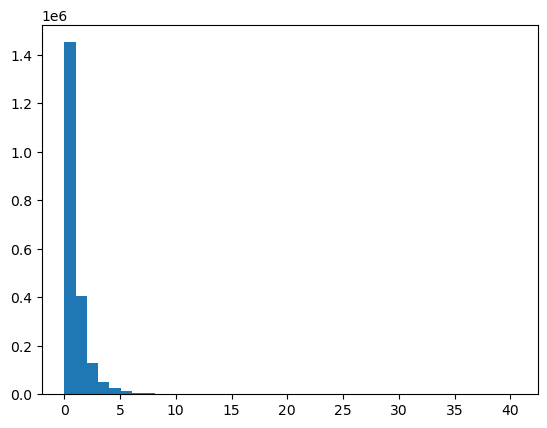

In [5]:
fig, ax = plt.subplots()
ax.hist(density.flatten(), bins=40)

(array([5.00000e+00, 6.20000e+01, 1.63000e+02, 5.22000e+02, 1.12400e+03,
        2.15000e+03, 3.95300e+03, 7.22100e+03, 1.24200e+04, 2.00620e+04,
        3.05210e+04, 4.34050e+04, 5.89920e+04, 7.69500e+04, 9.76690e+04,
        1.17894e+05, 1.35384e+05, 1.50744e+05, 1.62060e+05, 1.67540e+05,
        1.68036e+05, 1.60997e+05, 1.48604e+05, 1.31398e+05, 1.10017e+05,
        8.74050e+04, 6.63060e+04, 4.82340e+04, 3.38880e+04, 2.28730e+04,
        1.45390e+04, 8.29100e+03, 4.38000e+03, 2.05100e+03, 8.30000e+02,
        2.91000e+02, 1.10000e+02, 3.80000e+01, 1.50000e+01, 8.00000e+00]),
 array([-1.98765391, -1.89779072, -1.80792752, -1.71806433, -1.62820113,
        -1.53833793, -1.44847474, -1.35861154, -1.26874835, -1.17888515,
        -1.08902196, -0.99915876, -0.90929557, -0.81943237, -0.72956918,
        -0.63970598, -0.54984279, -0.45997959, -0.3701164 , -0.2802532 ,
        -0.19039001, -0.10052681, -0.01066362,  0.07919958,  0.16906277,
         0.25892597,  0.34878916,  0.43865236,  0

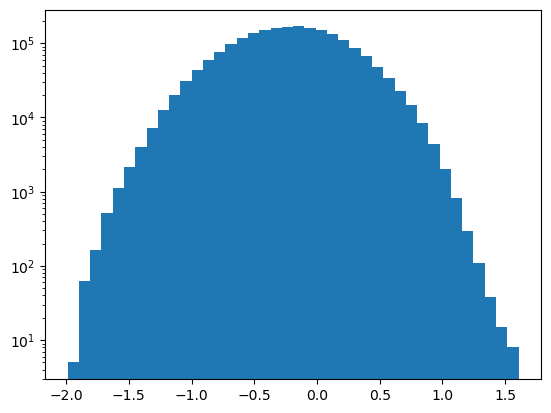

In [6]:
fig, ax = plt.subplots()
ax.hist(np.log10(density.flatten()), bins=40, log=True)

# variations in the spectral index

In [7]:
# vary the spectral index and store some realisations
d_1 = make_lognormal_density(N=N, spectral_index=1)
d_2 = make_lognormal_density(N=N, spectral_index=11./3.)
d_3 = make_lognormal_density(N=N, spectral_index=5)

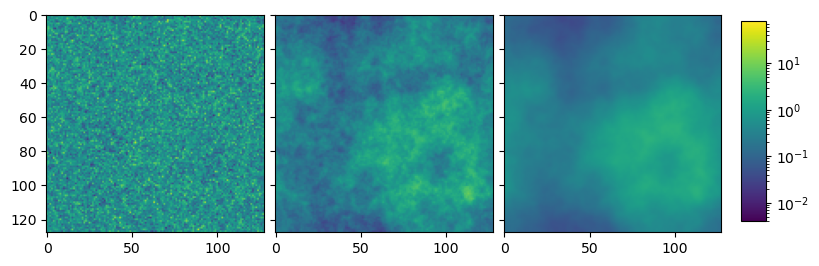

In [8]:
vmin, vmax = _get_min_max(d_1, d_2, d_3)

fig, axs = plt.subplots(figsize=(10,4),ncols=3,sharey=True)
im = axs[0].imshow(d_1[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))
im = axs[1].imshow(d_2[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))
im = axs[2].imshow(d_3[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))

fig.subplots_adjust(right=0.8, wspace=0.05)
cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
fig.colorbar(im, cax=cbar_ax)

In [9]:
# store data
np.save("data/density-cube-N"+str(N)+"-p1"+".npy", d_1)
np.save("data/density-cube-N"+str(N)+"-pKol"+".npy", d_2)
np.save("data/density-cube-N"+str(N)+"-p5"+".npy", d_1)

# variations in the random seed

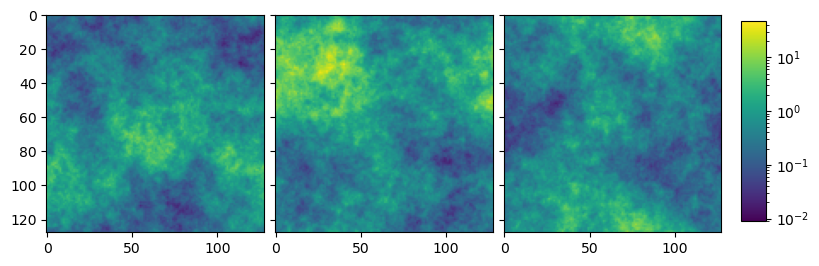

In [10]:
# different realisations, all with Kolmogorov slope
d_1 = make_lognormal_density(N=N, spectral_index=11./3., seed=43)
d_2 = make_lognormal_density(N=N, spectral_index=11./3., seed=44)
d_3 = make_lognormal_density(N=N, spectral_index=11./3., seed=45)

vmin, vmax = _get_min_max(d_1, d_2, d_3)

fig, axs = plt.subplots(figsize=(10,4),ncols=3,sharey=True)
im = axs[0].imshow(d_1[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))
im = axs[1].imshow(d_2[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))
im = axs[2].imshow(d_3[:,:,N//2], norm=LogNorm(vmin=vmin, vmax=vmax))
fig.subplots_adjust(right=0.8, wspace=0.05)
cbar_ax = fig.add_axes([0.82, 0.25, 0.025, 0.5])
fig.colorbar(im, cax=cbar_ax)

# store data
np.save("data/density-cube-N"+str(N)+"-pKol"+"-real1.npy", d_1)
np.save("data/density-cube-N"+str(N)+"-pKol"+"-real2.npy", d_2)
np.save("data/density-cube-N"+str(N)+"-pKol"+"-real3.npy", d_1)